<font color="Teal" face="Comic Sans MS,arial">
  <h1 align="center"><i>Clasificador con Transfer Learning- Clasificador de Enfermedades Dermatologicas Caninas</i></h1>
  </font>
  <font color="Black" face="Comic Sans MS,arial">
  <h5 align="center"><i>Profesor: José Eduardo Rodríguez Barrios</i></h5>
  <h5 align="center"><i>Ayudante: Carlos Cuauhtémoc Gutiérrez Salazar	</i></h5>
  <h5 align="center"><i>Materia:Proyecto 1 </i></h5>
   <h5 align="center"><i>Alumno : García Trejo Ricardo Fab
   ián</i></h5>
  <h5 align="center"><i>No.Cuenta: 318290953</i></h5>

In [1]:
#importamos librerias
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

import torch
from torch import nn
from torch.utils.data import DataLoader, random_split
import torch.nn.functional as F
from torchvision import datasets, transforms as T


from torchvision import datasets, transforms
#from torch.utils.data import dataset, DataLoader as dataloader
from PIL import Image
#import matplotlib.pyplot as plt
import numpy as np
import os
import shutil
#from pathlib import Path
#import torchvision.transforms as transforms
#from torchvision.transforms import ToPILImage

# Reproducibilidad basica
torch.manual_seed(0)
np.random.seed(0)

plt.rcParams["figure.figsize"] = (6, 4)
plt.rcParams["axes.grid"] = False

# **Preparacion de Datos**

In [2]:
#descomprimimos el data-set el cual fue comprimido para tener una mejor manipulacion
!unzip "/content/Dog_Skin_Diseases_mio_v2.zip" -d "/content/disease"
#este comando es para otra version de los datos
#!unzip "/content/Dog's skin diseases - Kaggle.zip" -d "/content/disease2"

Archive:  /content/Dog_Skin_Diseases_mio_v2.zip
   creating: /content/disease/test/
   creating: /content/disease/test/Bacterial_dermatosis/
  inflating: /content/disease/test/Bacterial_dermatosis/1000010516_x16_jpg.rf.bae3a88cf9d9240fad7046b65de2f235.jpg  
  inflating: /content/disease/test/Bacterial_dermatosis/1000010543_x16_jpg.rf.3d5c8fbd838ce372995e687752cdb307.jpg  
  inflating: /content/disease/test/Bacterial_dermatosis/1000010586_x4_jpg.rf.e950b7016d652bfd6bb59b0571a8a5ac.jpg  
  inflating: /content/disease/test/Bacterial_dermatosis/1000010597_x4_jpg.rf.e9ccc64314fe4b9fcb186f4d04167b9a.jpg  
  inflating: /content/disease/test/Bacterial_dermatosis/fly_strike_dermatitis_in_dogs_4935_6_600_jpg.rf.2b5cdf6cbc9b09d0dd7b67c66c2fc437.jpg  
  inflating: /content/disease/test/Bacterial_dermatosis/hot-spot-dog-paw-sh_1862261590_jpg.rf.e3dc26d0a6ee239b4917bcf24f0d3b12.jpg  
  inflating: /content/disease/test/Bacterial_dermatosis/red-circle-ri-1mo-450_jpg.rf.14141cbb655f1403ada014db2786585d

In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Dispositivo:", device)

Dispositivo: cuda


In [4]:
#directorio principal de las imagenes
DATA_DIR = Path("/content/disease")
# redimncion de las imagenes
IMAGE_SIZE = (256,256)
#Tamaño del batch
BATCH_SIZE = 32

transform_train = T.Compose([
    T.Resize(IMAGE_SIZE),
    T.RandomHorizontalFlip(p=0.5),
    T.ColorJitter(brightness=0.2, contrast=0.1, hue=0.05),
    T.RandomRotation(46),
    #T.CenterCrop(256),
    T.RandomApply([T.RandomResizedCrop(IMAGE_SIZE, scale=(0.8, 1.0)), T.CenterCrop(256)], p=0.5),
    #T.RandomResizedCrop(IMAGE_SIZE, scale=(0.8, 1.0)),
    T.ToTensor(),
    T.Normalize(mean=[0.5,0.5,0.5], std= [0.5,0.5,0.5]),
    ])

transform_general = T.Compose([
    T.Resize(IMAGE_SIZE),
    T.ToTensor(),
    T.Normalize(mean=[0.5,0.5,0.5], std= [0.5,0.5,0.5]),
])

train_dataset = datasets.ImageFolder(DATA_DIR / 'train', transform=transform_train)
val_dataset = datasets.ImageFolder(DATA_DIR / 'valid', transform=transform_general)
test_dataset = datasets.ImageFolder(DATA_DIR / 'test', transform=transform_general)



train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False,)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False,)

print(f"Train batches: {len(train_loader)} | Val batches: {len(val_loader)} | Test batches: {len(test_loader)}")

Train batches: 9 | Val batches: 3 | Test batches: 2


# **Entrenamiento del modelo**

In [5]:
#funcion de precision del modelo
def accuracy(model, loader):
    total_loss = 0.0
    num_correct = 0
    num_total = 0
    model.eval()
    model = model.to(device=device)
    with torch.no_grad():
        for (x, y) in loader:
          x = x.to(device=device, dtype=torch.float32)
          y = y.to(device=device, dtype=torch.long)
          scores = model(x)
          loss = F.cross_entropy(scores, y)
          total_loss += loss.item() * y.size(0)
          _, pred= scores.max(dim=1)
          num_correct += (pred == y).sum().item()
          num_total += pred.size(0)
    return total_loss / num_total ,num_correct / num_total

In [6]:
import torch.nn.functional as F

#función de entrenamiento
def train2(model,optimizer,epochs):
  history = {
        "train_loss": [],
        "train_acc": [],
        "val_loss": [],
        "val_acc": [],
        "presicion" : [],
        "recall" : [],
        "f1_score" : [],
      }

  model = model.to(device=device)
  classes = len(train_dataset.classes)
  for epoch in range(1,epochs + 1):
    running_correct = 0
    running_total = 0
    for (x,y) in train_loader:
      model.train
      x = x.to(device=device, dtype=torch.float32)
      y = y.to(device=device, dtype=torch.long)
      scores = model(x)

      cost = F.cross_entropy(input=scores, target=y.squeeze())

      optimizer.zero_grad()
      cost.backward()
      optimizer.step()

      running_correct += (scores.argmax(dim=1) == y).sum().item()
      running_total += y.size(0)

    train_acc = running_correct / running_total
    val_loss , val_acc = accuracy(model,val_loader)
    P,R,f1_score_val = Scores_faltantes(model,classes)
    history["train_loss"].append(cost)
    history["train_acc"].append(train_acc)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)
    history["presicion"].append(P)
    history["recall"].append(R)
    history["f1_score"].append(f1_score_val)

    #val_loss , val_acc = accuracy(model,val_loader)
    #print(f'Epoch : {epoch}, costo : {cost.item()},val_loss: {val_loss} val_acc: {val_acc}')
    print(
           f"Epoch {epoch:02d}/{epochs} | "
           f"train_loss={cost:.4f} train_acc={train_acc:.4f} | "
           f"val_loss={val_loss:.4f} val_acc={val_acc:.4f} | "
           f"Presicion = {P:.4f} Recall = {R:.4f} F1_Score = {f1_score_val:.4f}|  "
        )

  return history

In [7]:
#mostremos la matriz de confusion

def matriz_confusion(model,loader):
  model = model.to(device=device)
  classes = train_dataset.classes
  model.eval()

  all_preds = []
  all_targets = []

  with torch.no_grad():
      for x, y in loader:
          x = x.to(device=device, dtype=torch.float32, non_blocking=True)
          y = y.to(device=device, dtype=torch.long, non_blocking=True)

          logits = model(x)
          preds = logits.argmax(dim=1)

          all_preds.append(preds.cpu())
          all_targets.append(y.cpu())

  all_preds = torch.cat(all_preds)
  all_targets = torch.cat(all_targets)

  test_accuracy = (all_preds == all_targets).float().mean().item()
  print(f"Test accuracy: {test_accuracy:.4f}")

  # Matriz de confusion (sin dependencias externas)
  num_classes = len(classes)
  cm = torch.zeros((num_classes, num_classes), dtype=torch.int64)
  for t, p in zip(all_targets, all_preds):
      cm[t.long(), p.long()] += 1

  plt.figure(figsize=(9, 7))
  plt.imshow(cm.numpy(), interpolation="nearest", cmap="Blues")
  plt.title(f"Matriz de confusion - Test")
  plt.colorbar()

  tick_marks = np.arange(num_classes)
  plt.xticks(tick_marks, classes, rotation=45, ha="right")
  plt.yticks(tick_marks, classes)
  plt.xlabel("Prediccion")
  plt.ylabel("Etiqueta real")

  # Mostrar valores dentro de la matriz
  thresh = cm.max().item() / 2 if cm.max().item() > 0 else 0
  for i in range(num_classes):
      for j in range(num_classes):
          value = cm[i, j].item()
          plt.text(
              j,
              i,
              f"{value}",
              ha="center",
              va="center",
              color="white" if value > thresh else "black",
              fontsize=8,
          )

  plt.tight_layout()
  plt.show()

In [8]:
def Scores_faltantes(model,clases):
  #funcion para valores de la matriz de confusion
  # con esto obtenemos los valore de Recall, Precision y f1_score
  model.eval()

  all_preds = []
  all_targets = []

  with torch.no_grad():
      for x, y in test_loader:
          x = x.to(device=device, dtype=torch.float32, non_blocking=True)
          y = y.to(device=device, dtype=torch.long, non_blocking=True)

          logits = model(x)
          preds = logits.argmax(dim=1)

          all_preds.append(preds.cpu())
          all_targets.append(y.cpu())

  all_preds = torch.cat(all_preds)
  all_targets = torch.cat(all_targets)

  # Matriz de confusion (sin dependencias externas)
  num_classes = clases
  cm = torch.zeros((num_classes, num_classes), dtype=torch.int64)
  for t, p in zip(all_targets, all_preds):
      cm[t.long(), p.long()] += 1

 # Scores
  A = clases
  F1 = np.zeros(A)
  pre = np.zeros(A)
  re = np.zeros(A)
  for i in range(A):
    Aciertos = 0
    f_p = 0
    f_n = 0
    for j in range(A):
      if i==j:
        Aciertos = int(cm[i][j])
      else:
        f_p += int(cm[i][j])
        f_n += int(cm[j][i])
    if Aciertos ==0:
      F1[i] = 0
      pre[i] = 0
      re[i] = 0

    else:

      pre_i = Aciertos / (Aciertos + f_p)
      re_i = Aciertos / (Aciertos + f_n)
      f1_i = (2*(pre_i * re_i)) / (pre_i + re_i)

      F1[i] = f1_i
      pre[i] = pre_i
      re[i] = re_i

  Presicion = pre.sum()/A
  Recall = re.sum()/A
  F1_Score = F1.sum()/A
  #print(Presicion)
  #print(Recall)
  #print(F1_Score)
  return Presicion , Recall , F1_Score

In [9]:
def graficas(history):
  epochs_axis = np.arange(1, len(history["train_loss"]) + 1)

  plt.figure(figsize=(10, 4))

  plt.subplot(1, 3, 1)
  plt.plot(epochs_axis, history["train_loss"], label="train")
  plt.plot(epochs_axis, history["val_loss"], label="val")
  plt.title("Loss")
  plt.xlabel("Epoch")
  plt.legend()

  plt.subplot(1, 3, 2)
  plt.plot(epochs_axis, history["train_acc"], label="train")
  plt.plot(epochs_axis, history["val_acc"], label="val")
  plt.title("Accuracy")
  plt.xlabel("Epoch")
  plt.legend()

  plt.subplot(1, 3, 3)
  plt.plot(epochs_axis, history["presicion"], label="Presicion")
  plt.plot(epochs_axis, history["recall"], label="Recall")
  plt.plot(epochs_axis, history["f1_score"], label="F1_score")
  plt.title("Metricas")
  plt.xlabel("Epoch")
  plt.legend()


  plt.tight_layout()
  plt.show()

  #test_loss, test_acc = evaluate(model_resnet56, test_loader, device)
  #print(f"Test loss: {test_loss:.4f}")
  #print(f"Test accuracy: {test_acc:.4f}")

# Modelos

Probemos con otros modelos

In [10]:
from torchvision import models

## **Resnet18**

In [11]:
model_resnet18 = models.resnet18(pretrained=True)
model_resnet18


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 206MB/s]


ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [12]:
# se toma el modelo sin las capas de clases
model_aux = nn.Sequential(*list(model_resnet18.children())[:-1])
model_aux

Sequential(
  (0): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (2): ReLU(inplace=True)
  (3): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (4): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Con

In [13]:
#verificamos si se encuentra encendido el entrenamiento del modelo

for i, parameter in enumerate(model_aux.parameters()):
  parameter.requires_grad = False

In [14]:
#se congela el modelo
for i, parameter in enumerate(model_aux.parameters()):
  print(i, parameter.requires_grad)

0 False
1 False
2 False
3 False
4 False
5 False
6 False
7 False
8 False
9 False
10 False
11 False
12 False
13 False
14 False
15 False
16 False
17 False
18 False
19 False
20 False
21 False
22 False
23 False
24 False
25 False
26 False
27 False
28 False
29 False
30 False
31 False
32 False
33 False
34 False
35 False
36 False
37 False
38 False
39 False
40 False
41 False
42 False
43 False
44 False
45 False
46 False
47 False
48 False
49 False
50 False
51 False
52 False
53 False
54 False
55 False
56 False
57 False
58 False
59 False


In [15]:
#se ajusta al nuetro clasificador
# resnet18 recibe 512 capas antes de la clasificacion
model_resnet18_mod = nn.Sequential(model_aux,
                       nn.Flatten(),
                       nn.Linear(in_features=512, out_features=5, bias= True))

optimizer = torch.optim.Adam(model_resnet18_mod.parameters(), lr=0.05,betas=(0.9, 0.999))

In [16]:
historia_Resnet18 = train2(model_resnet18_mod,optimizer,20)

Epoch 01/20 | train_loss=14.0501 train_acc=0.2146 | val_loss=6.0771 val_acc=0.2125 | Presicion = 0.2250 Recall = 0.0849 F1_Score = 0.1106|  
Epoch 02/20 | train_loss=6.7223 train_acc=0.2950 | val_loss=5.7239 val_acc=0.3500 | Presicion = 0.2893 Recall = 0.2033 F1_Score = 0.2305|  
Epoch 03/20 | train_loss=1.6812 train_acc=0.4253 | val_loss=5.0100 val_acc=0.2875 | Presicion = 0.2357 Recall = 0.1528 F1_Score = 0.1828|  
Epoch 04/20 | train_loss=1.6432 train_acc=0.4330 | val_loss=5.9865 val_acc=0.4000 | Presicion = 0.3643 Recall = 0.5341 F1_Score = 0.2746|  
Epoch 05/20 | train_loss=0.6955 train_acc=0.5172 | val_loss=3.1728 val_acc=0.4875 | Presicion = 0.3857 Recall = 0.4167 F1_Score = 0.3712|  
Epoch 06/20 | train_loss=1.5019 train_acc=0.5134 | val_loss=3.9040 val_acc=0.4750 | Presicion = 0.3571 Recall = 0.4824 F1_Score = 0.3410|  
Epoch 07/20 | train_loss=4.3272 train_acc=0.5670 | val_loss=3.0458 val_acc=0.4375 | Presicion = 0.5179 Recall = 0.5648 F1_Score = 0.5227|  
Epoch 08/20 | train

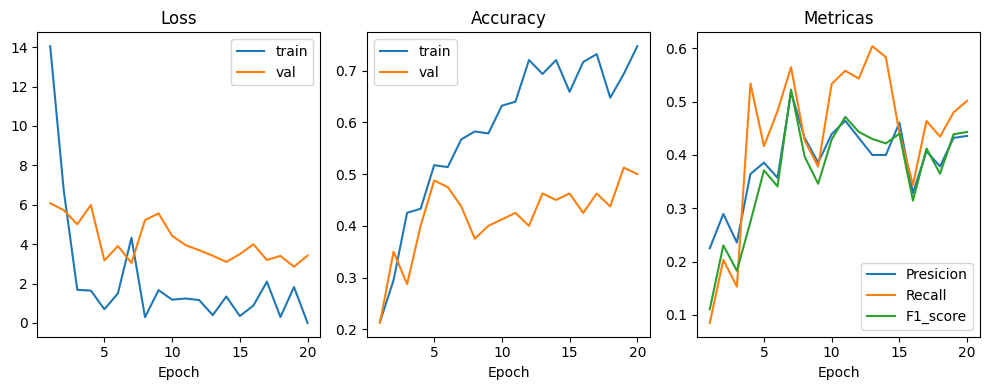

In [17]:
historia_Resnet18_plot = historia_Resnet18.copy()
historia_Resnet18_plot["train_loss"] = [loss.item() for loss in historia_Resnet18["train_loss"]]
graficas(historia_Resnet18_plot)

Test accuracy: 0.4324


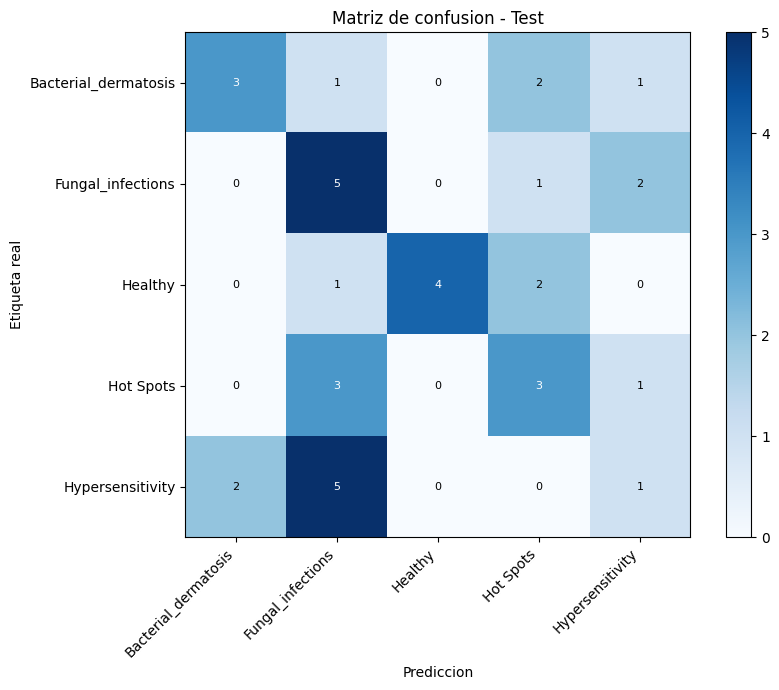

In [18]:
#mostramos la matriz de confusion del modelo
matriz_confusion(model_resnet18_mod,test_loader)

## **Resnet50**

In [19]:
model_resnet50 = models.resnet50(pretrained=True)
model_resnet50


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 173MB/s]


ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 

In [20]:
Aux_Resnet50 = nn.Sequential(*list(model_resnet50.children())[:-1])
Aux_Resnet50

Sequential(
  (0): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (2): ReLU(inplace=True)
  (3): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (4): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)


In [21]:
#verificamos si se encuentra encendido el entrenamiento del modelo
for i, parameter in enumerate(Aux_Resnet50.parameters()):
  print(i, parameter.requires_grad)

0 True
1 True
2 True
3 True
4 True
5 True
6 True
7 True
8 True
9 True
10 True
11 True
12 True
13 True
14 True
15 True
16 True
17 True
18 True
19 True
20 True
21 True
22 True
23 True
24 True
25 True
26 True
27 True
28 True
29 True
30 True
31 True
32 True
33 True
34 True
35 True
36 True
37 True
38 True
39 True
40 True
41 True
42 True
43 True
44 True
45 True
46 True
47 True
48 True
49 True
50 True
51 True
52 True
53 True
54 True
55 True
56 True
57 True
58 True
59 True
60 True
61 True
62 True
63 True
64 True
65 True
66 True
67 True
68 True
69 True
70 True
71 True
72 True
73 True
74 True
75 True
76 True
77 True
78 True
79 True
80 True
81 True
82 True
83 True
84 True
85 True
86 True
87 True
88 True
89 True
90 True
91 True
92 True
93 True
94 True
95 True
96 True
97 True
98 True
99 True
100 True
101 True
102 True
103 True
104 True
105 True
106 True
107 True
108 True
109 True
110 True
111 True
112 True
113 True
114 True
115 True
116 True
117 True
118 True
119 True
120 True
121 True
122 True
123

In [22]:
#se congela el modelo
for i, parameter in enumerate(Aux_Resnet50.parameters()):
  parameter.requires_grad = False

In [23]:
#se ajusta al nuetro clasificador
# resnet50 recibe 2048 capas antes de la clasificacion
model_resnet50_mod = nn.Sequential(Aux_Resnet50,
                       nn.Flatten(),
                       nn.Linear(in_features=2048, out_features=5, bias= True))

optimizer = torch.optim.Adam(model_resnet50_mod.parameters(), lr=0.05,betas=(0.9, 0.999))

ahora probamos el clasificador con el modelo Resnet50 mediante transfer learning

In [24]:
historia_Resnet50 = train2(model_resnet50_mod,optimizer,20)

Epoch 01/20 | train_loss=45.5394 train_acc=0.2452 | val_loss=21.2480 val_acc=0.2750 | Presicion = 0.2286 Recall = 0.0844 F1_Score = 0.1176|  
Epoch 02/20 | train_loss=0.8185 train_acc=0.3218 | val_loss=8.7650 val_acc=0.2500 | Presicion = 0.2607 Recall = 0.2835 F1_Score = 0.2350|  
Epoch 03/20 | train_loss=4.7684 train_acc=0.4368 | val_loss=13.3892 val_acc=0.2500 | Presicion = 0.2214 Recall = 0.0929 F1_Score = 0.1186|  
Epoch 04/20 | train_loss=13.8898 train_acc=0.4253 | val_loss=7.7761 val_acc=0.2750 | Presicion = 0.2357 Recall = 0.1648 F1_Score = 0.1912|  
Epoch 05/20 | train_loss=1.4772 train_acc=0.5287 | val_loss=6.8677 val_acc=0.3875 | Presicion = 0.3000 Recall = 0.4423 F1_Score = 0.3025|  
Epoch 06/20 | train_loss=0.6153 train_acc=0.5249 | val_loss=8.6643 val_acc=0.3875 | Presicion = 0.3357 Recall = 0.1969 F1_Score = 0.2357|  
Epoch 07/20 | train_loss=1.8868 train_acc=0.5594 | val_loss=9.8111 val_acc=0.3625 | Presicion = 0.3357 Recall = 0.2950 F1_Score = 0.2806|  
Epoch 08/20 | tr

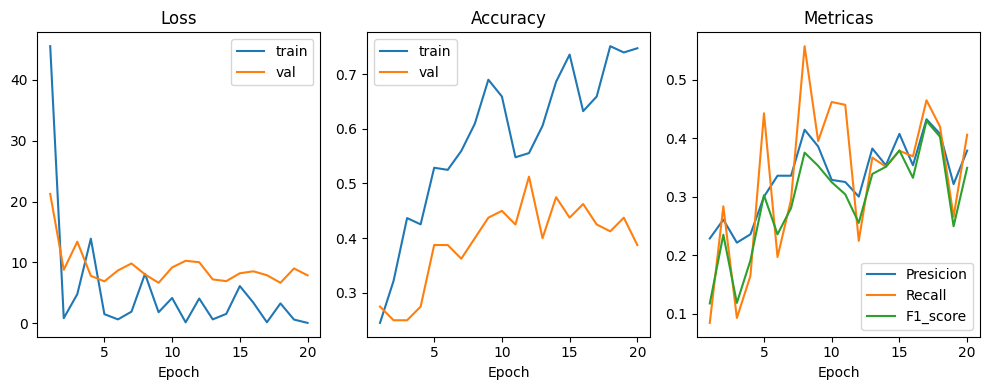

In [25]:
historia_Resnet50_plot = historia_Resnet50.copy()
historia_Resnet50_plot["train_loss"] = [loss.item() for loss in historia_Resnet50["train_loss"]]
graficas(historia_Resnet50_plot)

Test accuracy: 0.3784


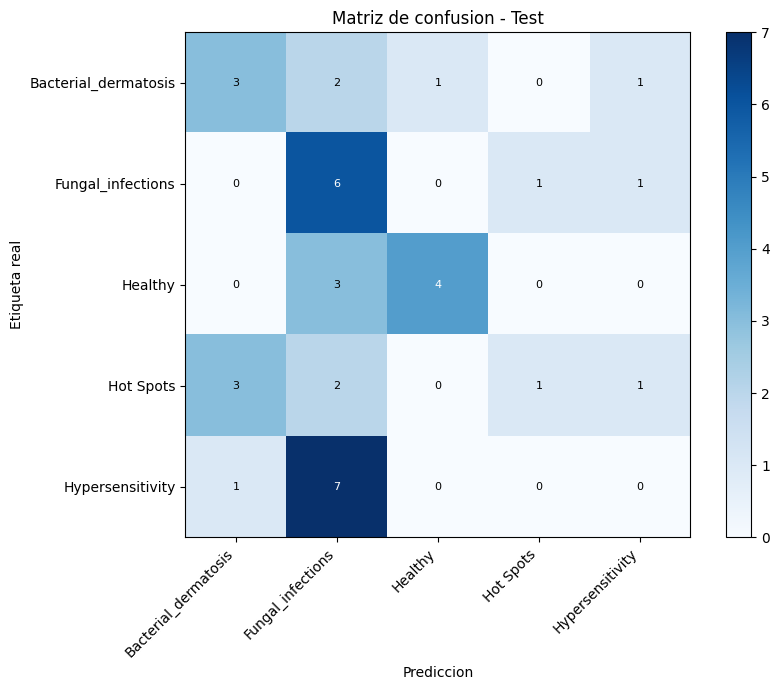

In [26]:
matriz_confusion(model_resnet50_mod,test_loader)

## **MobileNetV3**

In [27]:
model_mobilenetv3 = models.mobilenet_v3_small(pretrained=True)
model_mobilenetv3

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=MobileNet_V3_Small_Weights.IMAGENET1K_V1`. You can also use `weights=MobileNet_V3_Small_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/mobilenet_v3_small-047dcff4.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v3_small-047dcff4.pth


100%|██████████| 9.83M/9.83M [00:00<00:00, 185MB/s]


MobileNetV3(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(16, eps=0.001, momentum=0.01, affine=True, track_running_stats=True)
      (2): Hardswish()
    )
    (1): InvertedResidual(
      (block): Sequential(
        (0): Conv2dNormActivation(
          (0): Conv2d(16, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), groups=16, bias=False)
          (1): BatchNorm2d(16, eps=0.001, momentum=0.01, affine=True, track_running_stats=True)
          (2): ReLU(inplace=True)
        )
        (1): SqueezeExcitation(
          (avgpool): AdaptiveAvgPool2d(output_size=1)
          (fc1): Conv2d(16, 8, kernel_size=(1, 1), stride=(1, 1))
          (fc2): Conv2d(8, 16, kernel_size=(1, 1), stride=(1, 1))
          (activation): ReLU()
          (scale_activation): Hardsigmoid()
        )
        (2): Conv2dNormActivation(
          (0): Conv2d(16, 16, kernel_size=(1, 1), 

In [28]:
Aux_mobilenetv3 = nn.Sequential(*list(model_mobilenetv3.children())[:-1])
Aux_mobilenetv3

Sequential(
  (0): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(16, eps=0.001, momentum=0.01, affine=True, track_running_stats=True)
      (2): Hardswish()
    )
    (1): InvertedResidual(
      (block): Sequential(
        (0): Conv2dNormActivation(
          (0): Conv2d(16, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), groups=16, bias=False)
          (1): BatchNorm2d(16, eps=0.001, momentum=0.01, affine=True, track_running_stats=True)
          (2): ReLU(inplace=True)
        )
        (1): SqueezeExcitation(
          (avgpool): AdaptiveAvgPool2d(output_size=1)
          (fc1): Conv2d(16, 8, kernel_size=(1, 1), stride=(1, 1))
          (fc2): Conv2d(8, 16, kernel_size=(1, 1), stride=(1, 1))
          (activation): ReLU()
          (scale_activation): Hardsigmoid()
        )
        (2): Conv2dNormActivation(
          (0): Conv2d(16, 16, kernel_size=(1, 1), stride=(

In [29]:
#verificamos si se encuentra encendido el entrenamiento del modelo
for i, parameter in enumerate(Aux_mobilenetv3.parameters()):
  print(i, parameter.requires_grad)

0 True
1 True
2 True
3 True
4 True
5 True
6 True
7 True
8 True
9 True
10 True
11 True
12 True
13 True
14 True
15 True
16 True
17 True
18 True
19 True
20 True
21 True
22 True
23 True
24 True
25 True
26 True
27 True
28 True
29 True
30 True
31 True
32 True
33 True
34 True
35 True
36 True
37 True
38 True
39 True
40 True
41 True
42 True
43 True
44 True
45 True
46 True
47 True
48 True
49 True
50 True
51 True
52 True
53 True
54 True
55 True
56 True
57 True
58 True
59 True
60 True
61 True
62 True
63 True
64 True
65 True
66 True
67 True
68 True
69 True
70 True
71 True
72 True
73 True
74 True
75 True
76 True
77 True
78 True
79 True
80 True
81 True
82 True
83 True
84 True
85 True
86 True
87 True
88 True
89 True
90 True
91 True
92 True
93 True
94 True
95 True
96 True
97 True
98 True
99 True
100 True
101 True
102 True
103 True
104 True
105 True
106 True
107 True
108 True
109 True
110 True
111 True
112 True
113 True
114 True
115 True
116 True
117 True
118 True
119 True
120 True
121 True
122 True
123

In [30]:
#se congela el modelo
for i, parameter in enumerate(Aux_mobilenetv3.parameters()):
  parameter.requires_grad = False

In [31]:
#se ajusta al nuetro clasificador
# mobileNetV3_small recibe 576 capas antes de la clasificacion
model_mobilenetv3_mod = nn.Sequential(Aux_mobilenetv3,
                       nn.Flatten(),
                       nn.Linear(in_features=576, out_features=5, bias= True))

optimizer = torch.optim.Adam(model_mobilenetv3_mod.parameters(), lr=0.05,betas=(0.9, 0.999))

In [32]:
historia_mobilenetv3 = train2(model_mobilenetv3_mod,optimizer,20)

Epoch 01/20 | train_loss=3.9015 train_acc=0.3257 | val_loss=3.6591 val_acc=0.3875 | Presicion = 0.3143 Recall = 0.1885 F1_Score = 0.2096|  
Epoch 02/20 | train_loss=2.2928 train_acc=0.4176 | val_loss=3.3153 val_acc=0.4125 | Presicion = 0.4179 Recall = 0.3942 F1_Score = 0.3528|  
Epoch 03/20 | train_loss=1.3430 train_acc=0.4444 | val_loss=2.6869 val_acc=0.4750 | Presicion = 0.4429 Recall = 0.4571 F1_Score = 0.4349|  
Epoch 04/20 | train_loss=1.7197 train_acc=0.5057 | val_loss=3.3074 val_acc=0.4250 | Presicion = 0.3286 Recall = 0.5072 F1_Score = 0.3064|  
Epoch 05/20 | train_loss=0.4203 train_acc=0.5594 | val_loss=2.6856 val_acc=0.3875 | Presicion = 0.4429 Recall = 0.4833 F1_Score = 0.4351|  
Epoch 06/20 | train_loss=1.6292 train_acc=0.6667 | val_loss=2.6298 val_acc=0.5125 | Presicion = 0.4179 Recall = 0.5061 F1_Score = 0.3831|  
Epoch 07/20 | train_loss=0.7372 train_acc=0.6705 | val_loss=2.1712 val_acc=0.5125 | Presicion = 0.4679 Recall = 0.4909 F1_Score = 0.4531|  
Epoch 08/20 | train_

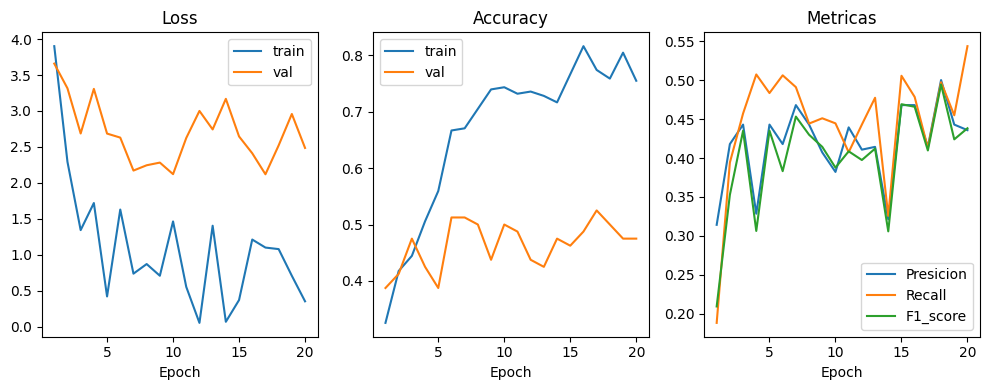

In [33]:
historia_mobilenetv3_plot = historia_mobilenetv3.copy()
historia_mobilenetv3_plot["train_loss"] = [loss.item() for loss in historia_mobilenetv3["train_loss"]]
graficas(historia_mobilenetv3_plot)

Test accuracy: 0.4324


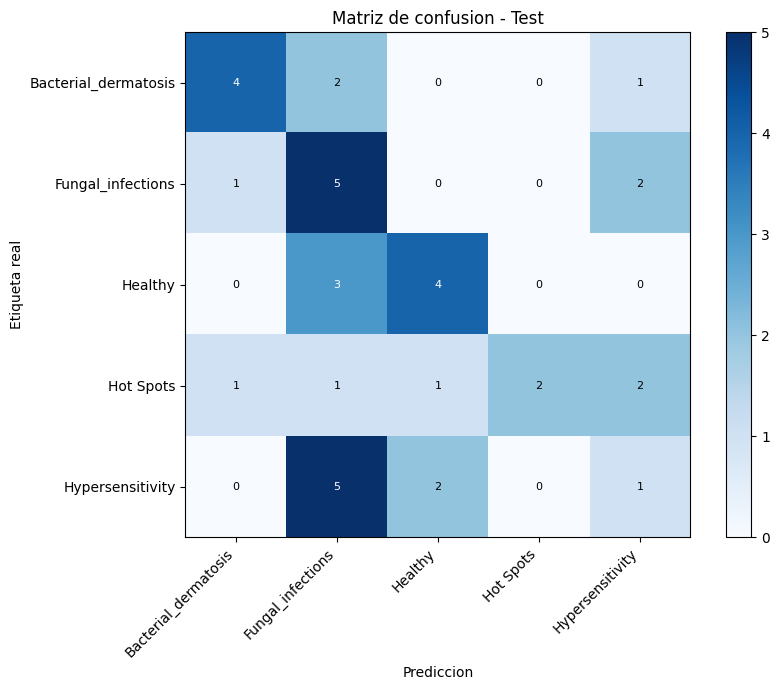

In [34]:
matriz_confusion(model_mobilenetv3_mod,test_loader)

## **DenseNet121**

In [35]:
model_DenseNet121 = models.densenet121(pretrained=True)
model_DenseNet121

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=DenseNet121_Weights.IMAGENET1K_V1`. You can also use `weights=DenseNet121_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/densenet121-a639ec97.pth" to /root/.cache/torch/hub/checkpoints/densenet121-a639ec97.pth


100%|██████████| 30.8M/30.8M [00:00<00:00, 203MB/s]


DenseNet(
  (features): Sequential(
    (conv0): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (norm0): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu0): ReLU(inplace=True)
    (pool0): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (denseblock1): _DenseBlock(
      (denselayer1): _DenseLayer(
        (norm1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu1): ReLU(inplace=True)
        (conv1): Conv2d(64, 128, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (norm2): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu2): ReLU(inplace=True)
        (conv2): Conv2d(128, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      )
      (denselayer2): _DenseLayer(
        (norm1): BatchNorm2d(96, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu

In [36]:
Aux_DenseNet121 = nn.Sequential(*list(model_DenseNet121.children())[:-1])
Aux_DenseNet121

Sequential(
  (0): Sequential(
    (conv0): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (norm0): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu0): ReLU(inplace=True)
    (pool0): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (denseblock1): _DenseBlock(
      (denselayer1): _DenseLayer(
        (norm1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu1): ReLU(inplace=True)
        (conv1): Conv2d(64, 128, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (norm2): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu2): ReLU(inplace=True)
        (conv2): Conv2d(128, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      )
      (denselayer2): _DenseLayer(
        (norm1): BatchNorm2d(96, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu1): R

In [37]:
#verificamos si se encuentra encendido el entrenamiento del modelo
for i, parameter in enumerate(Aux_DenseNet121.parameters()):
  print(i, parameter.requires_grad)

0 True
1 True
2 True
3 True
4 True
5 True
6 True
7 True
8 True
9 True
10 True
11 True
12 True
13 True
14 True
15 True
16 True
17 True
18 True
19 True
20 True
21 True
22 True
23 True
24 True
25 True
26 True
27 True
28 True
29 True
30 True
31 True
32 True
33 True
34 True
35 True
36 True
37 True
38 True
39 True
40 True
41 True
42 True
43 True
44 True
45 True
46 True
47 True
48 True
49 True
50 True
51 True
52 True
53 True
54 True
55 True
56 True
57 True
58 True
59 True
60 True
61 True
62 True
63 True
64 True
65 True
66 True
67 True
68 True
69 True
70 True
71 True
72 True
73 True
74 True
75 True
76 True
77 True
78 True
79 True
80 True
81 True
82 True
83 True
84 True
85 True
86 True
87 True
88 True
89 True
90 True
91 True
92 True
93 True
94 True
95 True
96 True
97 True
98 True
99 True
100 True
101 True
102 True
103 True
104 True
105 True
106 True
107 True
108 True
109 True
110 True
111 True
112 True
113 True
114 True
115 True
116 True
117 True
118 True
119 True
120 True
121 True
122 True
123

In [38]:
#se congela el modelo
for i, parameter in enumerate(Aux_DenseNet121.parameters()):
  parameter.requires_grad = False

In [39]:
#se ajusta al nuetro clasificador
# DenseNet121 recibe 1024 capas antes de la clasificacion
model_DenseNet121_mod = nn.Sequential(Aux_DenseNet121,
                       nn.Flatten(),
                       nn.Linear(in_features=65536, out_features=5, bias= True))

optimizer = torch.optim.Adam(model_DenseNet121_mod.parameters(), lr=0.05,betas=(0.9, 0.999))

In [40]:
historia_DenseNet121 = train2(model_DenseNet121_mod,optimizer,20)

Epoch 01/20 | train_loss=219.1247 train_acc=0.4023 | val_loss=213.2202 val_acc=0.4000 | Presicion = 0.2464 Recall = 0.2528 F1_Score = 0.2210|  
Epoch 02/20 | train_loss=237.8426 train_acc=0.5211 | val_loss=237.9311 val_acc=0.4125 | Presicion = 0.3214 Recall = 0.3782 F1_Score = 0.3137|  
Epoch 03/20 | train_loss=0.0000 train_acc=0.6284 | val_loss=298.3696 val_acc=0.4125 | Presicion = 0.3464 Recall = 0.3557 F1_Score = 0.3377|  
Epoch 04/20 | train_loss=0.0000 train_acc=0.7586 | val_loss=345.2097 val_acc=0.3000 | Presicion = 0.2464 Recall = 0.2462 F1_Score = 0.2356|  
Epoch 05/20 | train_loss=211.4269 train_acc=0.8046 | val_loss=296.6234 val_acc=0.4250 | Presicion = 0.2786 Recall = 0.2817 F1_Score = 0.2738|  
Epoch 06/20 | train_loss=0.0000 train_acc=0.8084 | val_loss=286.7107 val_acc=0.4375 | Presicion = 0.2536 Recall = 0.2317 F1_Score = 0.2414|  
Epoch 07/20 | train_loss=1.0095 train_acc=0.8238 | val_loss=311.4001 val_acc=0.4125 | Presicion = 0.3286 Recall = 0.3717 F1_Score = 0.3203|  


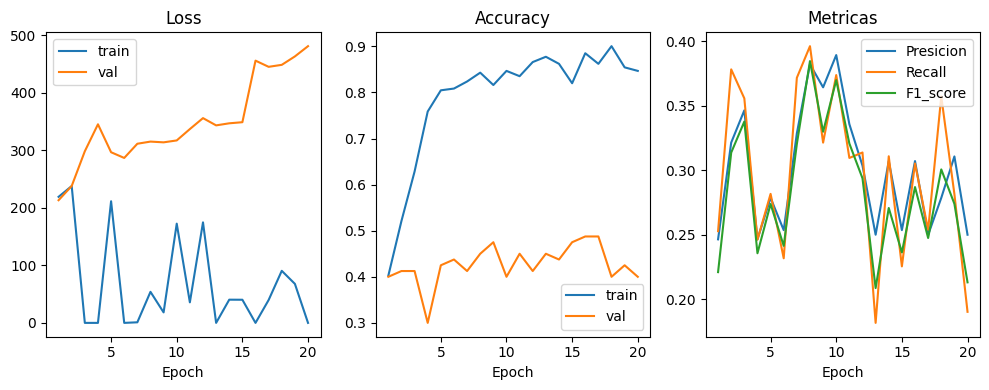

In [41]:
historia_DenseNet121_plot = historia_DenseNet121.copy()
historia_DenseNet121_plot["train_loss"] = [loss.item() for loss in historia_DenseNet121["train_loss"]]
graficas(historia_DenseNet121_plot)

Test accuracy: 0.2432


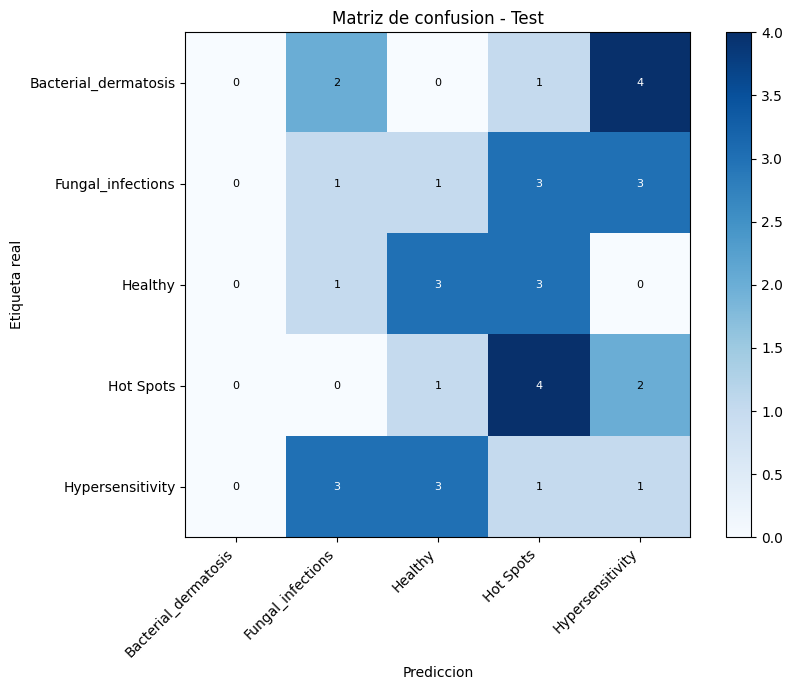

In [42]:
matriz_confusion(model_DenseNet121_mod,test_loader)

## **InceptionV3**

Este modelo no fue utilizado puesto que requiere modificaciones adicionales al conjunto de datos

In [43]:
model_InceptionV3 = models.inception_v3(pretrained=True)
model_InceptionV3

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=Inception_V3_Weights.IMAGENET1K_V1`. You can also use `weights=Inception_V3_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/inception_v3_google-0cc3c7bd.pth" to /root/.cache/torch/hub/checkpoints/inception_v3_google-0cc3c7bd.pth


100%|██████████| 104M/104M [00:00<00:00, 203MB/s] 


Inception3(
  (Conv2d_1a_3x3): BasicConv2d(
    (conv): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), bias=False)
    (bn): BatchNorm2d(32, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
  )
  (Conv2d_2a_3x3): BasicConv2d(
    (conv): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), bias=False)
    (bn): BatchNorm2d(32, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
  )
  (Conv2d_2b_3x3): BasicConv2d(
    (conv): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (bn): BatchNorm2d(64, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
  )
  (maxpool1): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
  (Conv2d_3b_1x1): BasicConv2d(
    (conv): Conv2d(64, 80, kernel_size=(1, 1), stride=(1, 1), bias=False)
    (bn): BatchNorm2d(80, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
  )
  (Conv2d_4a_3x3): BasicConv2d(
    (conv): Conv2d(80, 192, kernel_size=(3, 3), stri

In [44]:
Aux_InceptionV3 = nn.Sequential(*list(model_InceptionV3.children())[:-1])
Aux_InceptionV3

Sequential(
  (0): BasicConv2d(
    (conv): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), bias=False)
    (bn): BatchNorm2d(32, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
  )
  (1): BasicConv2d(
    (conv): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), bias=False)
    (bn): BatchNorm2d(32, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
  )
  (2): BasicConv2d(
    (conv): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (bn): BatchNorm2d(64, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
  )
  (3): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
  (4): BasicConv2d(
    (conv): Conv2d(64, 80, kernel_size=(1, 1), stride=(1, 1), bias=False)
    (bn): BatchNorm2d(80, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
  )
  (5): BasicConv2d(
    (conv): Conv2d(80, 192, kernel_size=(3, 3), stride=(1, 1), bias=False)
    (bn): BatchNorm2d(192, eps=0.001, moment

In [45]:
#verificamos si se encuentra encendido el entrenamiento del modelo
for i, parameter in enumerate(Aux_InceptionV3.parameters()):
  print(i, parameter.requires_grad)

0 True
1 True
2 True
3 True
4 True
5 True
6 True
7 True
8 True
9 True
10 True
11 True
12 True
13 True
14 True
15 True
16 True
17 True
18 True
19 True
20 True
21 True
22 True
23 True
24 True
25 True
26 True
27 True
28 True
29 True
30 True
31 True
32 True
33 True
34 True
35 True
36 True
37 True
38 True
39 True
40 True
41 True
42 True
43 True
44 True
45 True
46 True
47 True
48 True
49 True
50 True
51 True
52 True
53 True
54 True
55 True
56 True
57 True
58 True
59 True
60 True
61 True
62 True
63 True
64 True
65 True
66 True
67 True
68 True
69 True
70 True
71 True
72 True
73 True
74 True
75 True
76 True
77 True
78 True
79 True
80 True
81 True
82 True
83 True
84 True
85 True
86 True
87 True
88 True
89 True
90 True
91 True
92 True
93 True
94 True
95 True
96 True
97 True
98 True
99 True
100 True
101 True
102 True
103 True
104 True
105 True
106 True
107 True
108 True
109 True
110 True
111 True
112 True
113 True
114 True
115 True
116 True
117 True
118 True
119 True
120 True
121 True
122 True
123

In [46]:
#se congela el modelo
for i, parameter in enumerate(Aux_InceptionV3.parameters()):
  parameter.requires_grad = False

In [47]:
#se ajusta al nuetro clasificador
# InceptionV3 recibe 2048 capas antes de la clasificacion
model_InceptionV3_mod = nn.Sequential(Aux_InceptionV3,
                       nn.Flatten(),
                       nn.Linear(in_features=2048, out_features=5, bias= True))

optimizer = torch.optim.Adam(model_InceptionV3_mod.parameters(), lr=0.05,betas=(0.9, 0.999))

In [48]:
#es podible que falle por el tamaño de las imagenes, segun ia debe de ser de 299
#historia_InceptionV3 = train2(model_InceptionV3_mod,optimizer,20)